In [1]:
# ── Notebook 1: Data Pipeline ──────────────────────────────────────────────
# Paper: Pimentel, Roark & Cotterell (2020) "Phonotactic Complexity and Its
# Trade-offs", TACL 8, 1-18.  https://aclanthology.org/2020.tacl-1.1/
# We replicate + extend their bits-per-phoneme method to Hindi, Tamil,
# Telugu, English — all native to NorthEuraLex 0.9 with proper IPA.
# ───────────────────────────────────────────────────────────────────────────

import os, csv, json, math, random, urllib.request
from collections import defaultdict, Counter

# Kaggle has these pre-installed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

# ── Constants ──────────────────────────────────────────────────────────────
LANGUAGES  = ["hin", "tam", "tel", "eng"]
LANG_NAMES = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}

MULTIWORD_MARKER = "+"   # NorthEuraLex marks phrase-glosses with this in Segments
BOS, EOS         = "<s>", "</s>"   # word boundary tokens for LM training
N_FOLDS          = 10              # 10-fold CV, exactly matching the paper
RANDOM_SEED      = 42

DATA_DIR = "/kaggle/working/data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Setup complete.")
print(f"Languages: {[LANG_NAMES[l] for l in LANGUAGES]}")
print(f"CV folds:  {N_FOLDS}")

Setup complete.
Languages: ['Hindi', 'Tamil', 'Telugu', 'English']
CV folds:  10


In [2]:
BASE_URL = "https://raw.githubusercontent.com/lexibank/northeuralex/master/cldf/"
FILES    = ["forms.csv", "languages.csv", "parameters.csv"]

for fname in FILES:
    out_path = os.path.join(DATA_DIR, fname)
    if os.path.exists(out_path):
        print(f"{fname} already exists ({os.path.getsize(out_path):,} bytes) — skipping")
    else:
        print(f"Downloading {fname}...", end=" ")
        urllib.request.urlretrieve(BASE_URL + fname, out_path)
        print(f"done ({os.path.getsize(out_path):,} bytes)")

print("\nAll files ready.")


All files ready.


In [3]:
def load_forms(exclude_multiword=True):
    """
    Returns dict: lang_id -> list of dicts
        {concept, orth_form, phonemes: list[str]}

    'Segments' in NorthEuraLex is already space-tokenized IPA —
    multi-character units like affricates (tʃ) and long vowels (aː)
    are treated as single tokens. No further IPA parsing needed.
    """
    data    = defaultdict(list)
    dropped = defaultdict(int)

    with open(os.path.join(DATA_DIR, "forms.csv"), encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            lid  = row["Language_ID"]
            if lid not in LANGUAGES:
                continue
            segs = row["Segments"].strip()
            if not segs:
                continue
            phonemes = segs.split()

            # Drop multi-word phrase glosses
            if exclude_multiword and MULTIWORD_MARKER in phonemes:
                dropped[lid] += 1
                continue

            data[lid].append({
                "concept"   : row["Parameter_ID"],
                "orth_form" : row["Form"],
                "phonemes"  : phonemes,
            })

    print("Multi-word entries dropped (not real phonotactic sequences):")
    for lid in LANGUAGES:
        print(f"  {LANG_NAMES[lid]:<10} {dropped[lid]} dropped")

    return data

forms = load_forms()
print()
print("Words remaining after filter:")
for lid in LANGUAGES:
    print(f"  {LANG_NAMES[lid]:<10} {len(forms[lid])}")

Multi-word entries dropped (not real phonotactic sequences):
  Hindi      190 dropped
  Tamil      148 dropped
  Telugu     36 dropped
  English    45 dropped

Words remaining after filter:
  Hindi      1287
  Tamil      871
  Telugu     985
  English    976


In [4]:
def build_vocab(forms_by_lang):
    """Per-language phoneme inventory: lang -> sorted list of IPA symbols"""
    vocab = {}
    for lid, entries in forms_by_lang.items():
        phon_set = set()
        for e in entries:
            phon_set.update(e["phonemes"])
        # Add the boundary tokens used during LM training
        phon_set.update([BOS, EOS])
        vocab[lid] = sorted(phon_set)
    return vocab

vocab = build_vocab(forms)

print(f"{'Language':<12} {'Phoneme types':>14}  {'Sample (first 12)':}")
print("-" * 65)
for lid in LANGUAGES:
    sample = [p for p in vocab[lid] if p not in (BOS, EOS)][:12]
    print(f"{LANG_NAMES[lid]:<12} {len(vocab[lid])-2:>14}  {' '.join(sample)}")

Language      Phoneme types  Sample (first 12)
-----------------------------------------------------------------
Hindi                    82  aː b bʰ bː d dʒ dʒʰ dʰ dʰː dː eː f
Tamil                    48  b dʑ e eː g h i iː j k kː l
Telugu                   66  ai au aː b bʰ bː dʑ dʑː d̪ d̪ː e eː
English                  40  a b d dʒ e f g h iː j k l


In [5]:
rows = []
for lid in LANGUAGES:
    entries  = forms[lid]
    lengths  = [len(e["phonemes"]) for e in entries]
    rows.append({
        "Language"          : LANG_NAMES[lid],
        "Family"            : "Indo-Aryan" if lid == "hin" else
                              "Dravidian"  if lid in ("tam","tel") else
                              "Germanic",
        "Words"             : len(entries),
        "Phoneme inventory" : len(vocab[lid]) - 2,   # exclude BOS/EOS
        "Avg word length"   : round(np.mean(lengths), 2),
        "Min length"        : min(lengths),
        "Max length"        : max(lengths),
        "Std length"        : round(np.std(lengths), 2),
    })

summary_df = pd.DataFrame(rows).set_index("Language")
print(summary_df.to_string())

              Family  Words  Phoneme inventory  Avg word length  Min length  Max length  Std length
Language                                                                                           
Hindi     Indo-Aryan   1287                 82             4.79           2          12        1.44
Tamil      Dravidian    871                 48             6.06           1          14        2.28
Telugu     Dravidian    985                 66             6.50           2          16        2.44
English     Germanic    976                 40             4.15           1          10        1.36


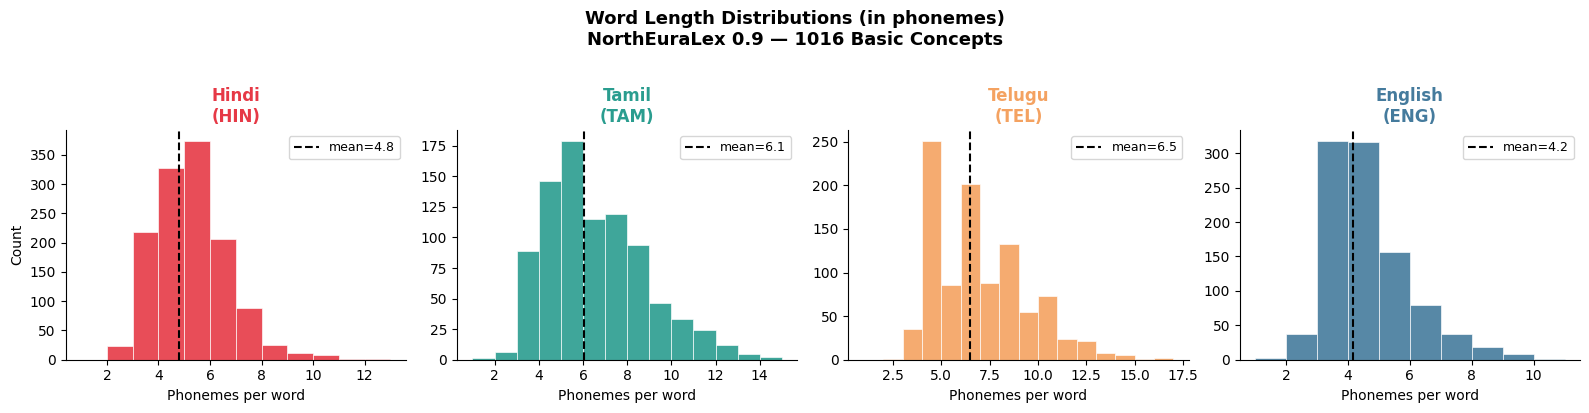

Saved: fig1_length_distributions.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
fig.suptitle("Word Length Distributions (in phonemes)\nNorthEuraLex 0.9 — 1016 Basic Concepts",
             fontsize=13, fontweight="bold", y=1.02)

for ax, lid in zip(axes, LANGUAGES):
    lengths = [len(e["phonemes"]) for e in forms[lid]]
    ax.hist(lengths, bins=range(1, max(lengths)+2), color=LANG_COLORS[lid],
            edgecolor="white", linewidth=0.5, alpha=0.9)
    ax.axvline(np.mean(lengths), color="black", linestyle="--",
               linewidth=1.5, label=f"mean={np.mean(lengths):.1f}")
    ax.set_title(f"{LANG_NAMES[lid]}\n({LANG_NAMES[lid][0:3].upper()})",
                 fontweight="bold", color=LANG_COLORS[lid])
    ax.set_xlabel("Phonemes per word")
    ax.set_ylabel("Count" if lid == "hin" else "")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig1_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_length_distributions.png")

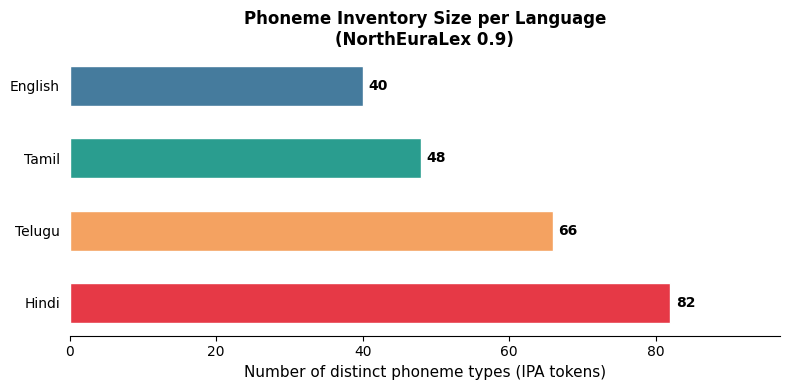

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

langs_sorted = sorted(LANGUAGES, key=lambda l: len(vocab[l]), reverse=True)
inv_sizes    = [len(vocab[l]) - 2 for l in langs_sorted]
colors       = [LANG_COLORS[l] for l in langs_sorted]
labels       = [LANG_NAMES[l] for l in langs_sorted]

bars = ax.barh(labels, inv_sizes, color=colors, edgecolor="white", height=0.55)
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_xlabel("Number of distinct phoneme types (IPA tokens)", fontsize=11)
ax.set_title("Phoneme Inventory Size per Language\n(NorthEuraLex 0.9)",
             fontweight="bold", fontsize=12)
ax.spines[["top","right","left"]].set_visible(False)
ax.set_xlim(0, max(inv_sizes) + 15)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig2_inventory_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Get the full list of concepts that appear in ALL 4 languages
# (for fair cross-linguistic comparison)
concept_sets = [set(e["concept"] for e in forms[lid]) for lid in LANGUAGES]
shared_concepts = sorted(concept_sets[0].intersection(*concept_sets[1:]))

print(f"Concepts appearing in all 4 languages: {len(shared_concepts)}")

# 10-fold split on concept IDs
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
concept_array = np.array(shared_concepts)

folds = []   # list of 10 dicts: {train_concepts, test_concepts}
for train_idx, test_idx in kf.split(concept_array):
    folds.append({
        "train" : set(concept_array[train_idx]),
        "test"  : set(concept_array[test_idx]),
    })

print(f"\nFold sizes (concepts):")
print(f"  Train: ~{len(folds[0]['train'])}  |  Test: ~{len(folds[0]['test'])}")

# Build per-language per-fold word lists
def get_split_words(lang_entries, concept_set):
    return [e["phonemes"] for e in lang_entries if e["concept"] in concept_set]

splits = {}   # lang -> list of 10 {train: [[phoneme list],...], test: [...]}
for lid in LANGUAGES:
    splits[lid] = []
    for fold in folds:
        splits[lid].append({
            "train" : get_split_words(forms[lid], fold["train"]),
            "test"  : get_split_words(forms[lid], fold["test"]),
        })

# Verify
print(f"\nWords per fold (Fold 0 example):")
for lid in LANGUAGES:
    tr = len(splits[lid][0]["train"])
    te = len(splits[lid][0]["test"])
    print(f"  {LANG_NAMES[lid]:<10}  train={tr}  test={te}")

Concepts appearing in all 4 languages: 751

Fold sizes (concepts):
  Train: ~675  |  Test: ~76

Words per fold (Fold 0 example):
  Hindi       train=998  test=107
  Tamil       train=678  test=76
  Telugu      train=679  test=76
  English     train=678  test=77


In [10]:
# Save clean forms
with open("/kaggle/working/forms.json", "w", encoding="utf-8") as f:
    json.dump(forms, f, ensure_ascii=False)

# Save vocab
with open("/kaggle/working/vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False)

# Save splits (concept sets per fold)
# Convert sets to lists for JSON serialization
serializable_folds = [
    {"train": list(fold["train"]), "test": list(fold["test"])}
    for fold in folds
]
with open("/kaggle/working/folds.json", "w", encoding="utf-8") as f:
    json.dump(serializable_folds, f)

# Save summary table
summary_df.to_csv("/kaggle/working/table1_summary.csv")

print("Saved:")
print("  /kaggle/working/forms.json          ← cleaned IPA word entries")
print("  /kaggle/working/vocab.json          ← phoneme inventories")
print("  /kaggle/working/folds.json          ← 10 concept-level CV folds")
print("  /kaggle/working/table1_summary.csv  ← Table 1 for writeup")

Saved:
  /kaggle/working/forms.json          ← cleaned IPA word entries
  /kaggle/working/vocab.json          ← phoneme inventories
  /kaggle/working/folds.json          ← 10 concept-level CV folds
  /kaggle/working/table1_summary.csv  ← Table 1 for writeup


In [12]:
print("━"*68)
print(f"{'Concept':<14} {'Hindi':<18} {'Tamil':<18} {'Telugu':<18} English")
print("━"*68)

spot_concepts = {
    "1_eye"   : "eye",
    "2_ear"   : "ear",
    "3_nose"  : "nose",
    "4_mouth" : "mouth", 
    "28_hand" : "hand",    
    "5_tooth" : "tooth",
    "6_tongue": "tongue",
}

for concept_id, gloss in spot_concepts.items():
    row = [f"{gloss} ({concept_id})"]
    for lid in LANGUAGES:
        entry = next((e for e in forms[lid] if e["concept"] == concept_id), None)
        row.append(" ".join(entry["phonemes"]) if entry else "—")
    print(f"{row[0]:<14} {row[1]:<18} {row[2]:<18} {row[3]:<18} {row[4]}")

print("━"*68)
print("\nNotebook 1 complete. All outputs saved to /kaggle/working/")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Concept        Hindi              Tamil              Telugu             English
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
eye (1_eye)    ãː kʰ              k ʌ ɳ              k ʌ n̪ː u          a ɪ
ear (2_ear)    k aː n             k ɑː t̪ u          tɕ e ʋ i           ɪ ə
nose (3_nose)  n aː k             m uː kː u          m u kː u           n ə ʊ z
mouth (4_mouth) m ʊ kʰ             ʋ ɑː j             n̪ oː r u          m a ʊ θ
hand (28_hand) h aː tʰ            k ʌ i              tɕ eː j i          h æ n d
tooth (5_tooth) d ə n t            p ʌ l              p ʌ lː u           t uː θ
tongue (6_tongue) dʒ iː bʰ           n̪ ɑː kː u         n̪ aː l u k ʌ      t ʌ ŋ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Notebook 1 complete. All outputs saved to /kaggle/working/
